## Step 1: Load Dataset

Goal:
Load raw ecommerce transaction data into a DataFrame for analysis.

Why:
We need to inspect structure, data types, and potential data quality issues before cleaning.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/raw/ecommerce_data.csv', encoding='ISO-8859-1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Step 2: Initial Data Inspection

Goal:
Understand dataset size, structure, and column types.

What we are checking:
- Number of rows and columns
- Column names
- Data types
- Missing values

In [2]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Step 3: Handle Missing Customer IDs

Goal:
Remove transactions that cannot be tied to a specific customer.

Why:
CustomerID is required for:
- RFM segmentation
- Retention analysis
- CLV modeling

Dropping these rows ensures valid customer-level analysis.

In [3]:
df = df.dropna(subset=['CustomerID'])

## Step 4: Fix Data Types

Goal:
Convert columns to correct formats.

Changes:
- Convert InvoiceDate to datetime for time-based analysis
- Convert CustomerID to string (categorical identifier)

Why:
Correct data types are critical for grouping, filtering, and time analysis.

In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = df["CustomerID"].astype(str)

## Step 5: Remove Invalid Transactions

Goal:
Filter out incorrect or non-revenue transactions.

What we remove:
- Quantity <= 0 → returns/cancellations
- UnitPrice <= 0 → invalid pricing

Why:
Including these would distort revenue and customer value calculations.

In [5]:
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

## Step 6: Create Revenue Feature

Goal:
Calculate total revenue per transaction line.

Formula:
Revenue = Quantity × UnitPrice

Why:
This enables:
- Sales analysis
- Customer value analysis
- Aggregations by time, country, product

In [6]:
df["SalesAmount"] = df["Quantity"] * df["UnitPrice"]

## Step 7: Verify Cleaned Dataset

Goal:
Check how data size changed after cleaning.

Why:
Understanding how much data was removed helps assess data quality impact.

In [7]:
df.shape

(397884, 9)

## Step 8: Exploratory Data Analysis (EDA)

Goal:
Identify key business patterns in the data.

We will analyze:
- Revenue trends over time
- Top performing countries
- Top selling products

### Time-Based Analysis

We analyze revenue trends over time to understand growth patterns, seasonality, and potential business cycles.

In [8]:
# Create time feature

df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='YearMonth'>

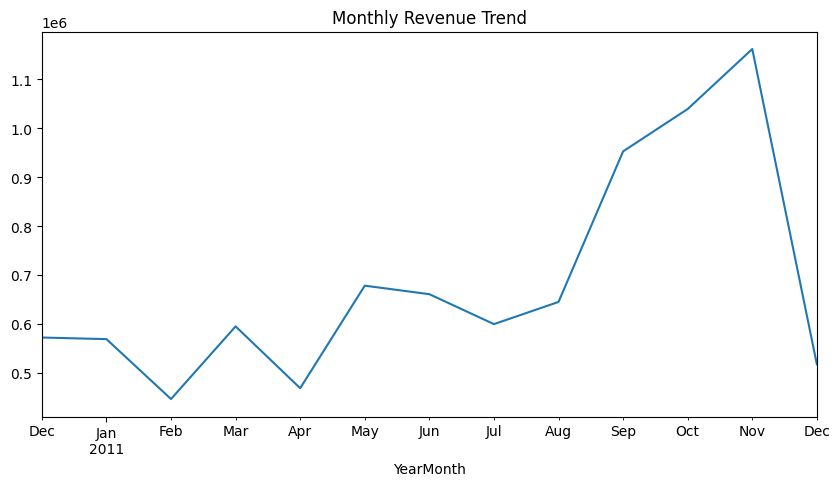

In [9]:
monthly_sales = df.groupby("YearMonth")["SalesAmount"].sum()

monthly_sales.plot(figsize=(10, 5), title="Monthly Revenue Trend")

### Insight: Revenue Trend

- Revenue shows a strong upward trend from mid-year into Q4.
- Peak revenue occurs in November, suggesting seasonal demand (e.g., holidays).
- The sharp drop in December is likely due to incomplete data for that month rather than actual decline.

In [10]:
# Top Countries

country_sales = df.groupby("Country")["SalesAmount"].sum().sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: SalesAmount, dtype: float64

### Insight: Geographic Performance

- The United Kingdom overwhelmingly dominates total sales, contributing the majority of revenue.
- This indicates the business is heavily concentrated in a single geographic market, which may present both opportunities and risks.

In [11]:
# Top Products

product_sales = df.groupby("Description")["SalesAmount"].sum().sort_values(ascending=False)

product_sales.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: SalesAmount, dtype: float64

### Insight: Product Performance

- Revenue is highly concentrated among a small number of top-performing products.
- This suggests a skewed product distribution where a limited set of items drives the majority of sales.

In [12]:
# Customer Metrics 

df["CustomerID"].nunique()

4338

In [13]:
df["InvoiceNo"].nunique()

18532

In [14]:
df.shape[0] / df["InvoiceNo"].nunique()

21.470105763004533

### Insight: Customer & Transaction Volume

- The dataset includes approximately 4,338 unique customers and 18,532 unique transactions.
- Each transaction consists of multiple line items, with an average of ~21 products per transaction.
- This indicates that purchases are basket-based rather than single-item, suggesting customers tend to buy multiple products per order.

In [15]:
summary = df.groupby("Country").agg(
    total_sales=("SalesAmount", "sum"),
    total_transactions=("InvoiceNo", "nunique"),
    total_customers=("CustomerID", "nunique")
).sort_values(by="total_sales", ascending=False)

summary.to_excel("../excel/EDA_KPI_Summary.xlsx")

In [16]:
df.to_csv("../data/processed/ecommerce_cleaned.csv", index=False)